In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

In [2]:
envs = ["atari_battle_zone", "atari_double_dunk", "atari_phoenix", "atari_this_game", "atari_battle_zone", "box2d_lunar_lander", "box2d_continuous_lunar_lander", "box2d_bipedal_walker", "cc_acrobot", "cc_cartpole", "cc_mountain_car", "cc_continuous_mountain_car", "cc_pendulum", "minigrid_door_key", "minigrid_empty_random", "minigrid_four_rooms", "minigrid_unlock", "brax_ant", "brax_halfcheetah", "brax_hopper", "brax_humanoid"]
algos = ["ppo", "dqn", "sac"]

data = []
for env in envs:
    for algo in algos:
        try:
            partial_data = pd.read_csv(f"arlbench_data/256_10/{env}_{algo}.csv")
            partial_data["env_name"] = env
            partial_data["algorithm"] = algo
            data.append(partial_data)
        except FileNotFoundError:
            continue
data = pd.concat(data)

In [3]:
## add domain
data["domain"] = data["env_name"].apply(lambda x: x.split("_")[0])

In [4]:
# normalization cross-algorithm per environment
data["normed_performance"] = data.groupby("env_name")["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["normed_performance_per_alg"] = data.groupby(["env_name", "algorithm"])["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["_seed_avg"] = data.groupby(["env_name", "algorithm", "config_id"])["performance"].transform("mean")
data["normed_performance_per_alg_seedavg"] = data.groupby(["env_name", "algorithm"], group_keys=False).apply(
    lambda g: (g["performance"] - g["_seed_avg"].min()) / (g["_seed_avg"].max() - g["_seed_avg"].min() + 1e-8)
)
data.drop(columns=["_seed_avg"], inplace=True)

/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_27386/355322313.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data["normed_performance_per_alg_seedavg"] = data.groupby(["env_name", "algorithm"], group_keys=False).apply(


In [5]:
# remove trash environments because they kill the cross-environment ranking later
bad_envs = ["cc_mountain_car", "minigrid_unlock"]
data = data[~data["env_name"].isin(bad_envs)]

In [6]:
def compute_rankings_counting(mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    """
    Compute rankings based on counting overlaps, without sorting or binary search.
    
    For each configuration j, we count:
    - How many configurations have upper bound (μ + σ) below j's lower bound (μ - σ)
      → these are strictly worse (gives lower bound on rank)
    - How many configurations have lower bound (μ - σ) below j's upper bound (μ + σ)
      → these overlap or are worse (gives upper bound on rank)
    
    The rank is the average of these bounds.
    
    Args:
        mu: Array of shape (n,) with aggregate metrics for each configuration
        sigma: Array of shape (n,) with spread metrics for each configuration
    
    Returns:
        ranks: Array of shape (n,) with the computed rank for each configuration
    """
    n = len(mu)
    
    # Compute bounds for all configurations
    upper_bounds = mu + sigma  # Best case for each config
    lower_bounds = mu - sigma  # Worst case for each config
    
    # For each configuration j, compute rank bounds
    l = np.zeros(n)  # Lower rank bound (1-indexed rank)
    u = np.zeros(n)  # Upper rank bound (1-indexed rank)
    
    for j in range(n):
        # Count how many configurations are strictly better than j
        # (their lower bound is above j's upper bound)
        strictly_better = np.sum(lower_bounds > upper_bounds[j])
        
        # Count how many configurations could potentially be better or equal
        # (their upper bound is at or above j's lower bound)
        potentially_better_or_equal = np.sum(upper_bounds >= lower_bounds[j])
        
        # l[j] = number of configs strictly better + 1 (best possible rank for j)
        l[j] = strictly_better + 1
        
        # u[j] = number of configs that could be better or equal (worst possible rank for j)
        u[j] = potentially_better_or_equal
    
    # Average rank
    ranks = (l + u) / 2
    
    return ranks

def compute_rankings_binary(mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    # Step 1: Sort by upper bound
    r_idx = np.argsort(mu + sigma)
    mu_sorted = mu[r_idx]
    sigma_sorted = sigma[r_idx]
    n = len(mu)
    ranks = np.zeros(n)

    # Precompute bounds
    upper_bounds = mu_sorted + sigma_sorted
    lower_bounds = mu_sorted - sigma_sorted

    for j in range(n):
        # Step 5: uj = binary_search(lower_bounds, mu[j] + sigma[j])
        uj = np.searchsorted(lower_bounds, mu[j] + sigma[j], side='right')
        # Step 6: lj = binary_search(upper_bounds, mu[j] - sigma[j])
        lj = np.searchsorted(upper_bounds, mu[j] - sigma[j], side='left')
        # Step 8: Average rank
        ranks[j] = (lj + uj) / 2

    # Reorder ranks to original order
    ranks_final = np.zeros(n)
    ranks_final[r_idx] = ranks
    return ranks_final

#### Remark: Because we work with ranks, this is invariant under normalization

i.e. it doesnt matter which performance column we use

In [7]:
perf_column = "normed_performance_per_alg"

In [8]:
def bootstrap_ci(data, n_boot=100, ci=95):
    boot_means = []
    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))
    mean = np.mean(boot_means)
    half_width = (np.percentile(boot_means, 97.5) - np.percentile(boot_means, 2.5)) / 2
    return mean, half_width

In [9]:
rank_dict = {}  
envs = data["env_name"].unique()
algos = data["algorithm"].unique()

for algo in algos:
    rank_dict[algo] = {}
    for env in envs:

        subset = data[(data["env_name"] == env) & (data["algorithm"] == algo)]

        hp_config_cols = [col for col in subset.columns 
                        if col.startswith('hp_config.') and subset[col].notna().all()]

        # all potential hyperparameters for this algo-env pair
        H = [col.replace("hp_config.", "") for col in hp_config_cols]

        for i, H_i in enumerate(H):     # enumerate over all hyperaparameters

            h_j_vals = []
            mu, sigma = [], []

            for j, h_j in enumerate(subset[f"hp_config.{H_i}"].unique().tolist()):      # all observations of this hyperparameter
                
                subsubset = subset[subset[f"hp_config.{H_i}"] == h_j]

                h_j_vals.append(h_j)
                # mu.append(subsubset[perf_column].mean())
                # sigma.append(subsubset[perf_column].std())

                mean, ci_half_width = bootstrap_ci(subsubset[perf_column].values)
                mu.append(mean)
                sigma.append(ci_half_width)

            # convert to numpy arrays
            vals = np.array(h_j_vals)           # not really used anywhere
            mu = np.array(mu)
            sigma = np.array(sigma)

            # sigma = sigma / 4       # make smaller intervals for overlap

            ranks_i = compute_rankings_binary(mu, sigma)

            rank_dict[algo].setdefault(H_i, {})[env] = ranks_i


In [10]:
# rank_dict["ppo"]

In [11]:
rank_dfs = {}
for algo in algos:
    rank_dfs[algo] = {}
    for H_i, env_ranks in rank_dict[algo].items():
        rows = []
        for env, ranks in env_ranks.items():
            row = {"env_name": env}
            for idx, val in enumerate(ranks):
                row[idx + 1] = val
            rows.append(row)
        df = pd.DataFrame(rows).set_index("env_name").T
        df = df[sorted(df.columns)]  # sort columns by env_name

        # Add ptp (peak-to-peak) as the first column
        df.insert(0, "ptp", df.max(axis=1) - df.min(axis=1))

        # normed ptp is obtained by dividing through the number of rows - 1
        # insert this new column right after ptp
        df.insert(1, "normed_ptp", df["ptp"] / (len(df)) if len(df) > 1 else 0)

        
        rank_dfs[algo][H_i] = df


In [17]:
# Example: view clip_eps ranks
rank_dfs["ppo"]["clip_eps"]

env_name,ptp,normed_ptp,atari_battle_zone,atari_double_dunk,atari_phoenix,atari_this_game,box2d_bipedal_walker,box2d_continuous_lunar_lander,box2d_lunar_lander,brax_ant,brax_halfcheetah,brax_hopper,brax_humanoid,cc_acrobot,cc_cartpole,cc_continuous_mountain_car,cc_pendulum,minigrid_door_key,minigrid_empty_random,minigrid_four_rooms
1,175.5,0.685547,206.0,116.5,57.0,99.0,124.5,95.0,204.0,121.5,111.5,207.5,149.5,90.0,116.5,109.5,139.0,113.5,101.0,32.0
2,160.0,0.625000,211.5,126.0,197.0,94.5,226.5,189.5,98.5,209.5,221.0,200.0,134.5,80.5,66.5,156.0,100.0,113.5,81.5,164.0
3,185.5,0.724609,96.5,120.0,62.5,192.0,136.5,104.0,98.5,171.5,203.0,235.0,189.0,213.5,69.0,108.5,62.5,248.0,72.0,158.0
4,135.0,0.527344,111.0,122.0,189.5,122.0,204.0,72.0,190.0,99.5,69.5,176.0,111.5,102.0,201.5,117.5,69.0,113.5,124.0,155.0
5,184.0,0.718750,119.5,109.5,224.5,177.5,197.5,83.0,123.5,69.0,164.0,40.5,109.5,208.5,58.5,155.5,163.5,113.5,126.5,122.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,223.5,0.873047,65.0,177.0,61.5,95.0,95.0,252.0,116.0,123.0,245.5,107.5,28.5,195.0,65.5,222.5,147.0,113.5,158.0,64.0
253,196.5,0.767578,205.0,198.5,107.0,127.0,124.0,111.0,98.5,169.5,24.0,110.5,220.5,85.0,187.0,102.5,158.5,113.5,98.5,143.5
254,222.5,0.869141,101.5,122.0,68.0,93.5,97.0,126.0,102.5,212.5,157.0,18.5,173.0,91.0,180.0,223.0,129.0,241.0,111.0,175.5
255,148.0,0.578125,184.0,123.5,57.0,132.0,201.5,73.5,190.5,204.0,56.0,171.5,184.5,88.0,80.0,190.5,159.0,113.5,115.0,126.5


In [13]:
# rank_dfs["ppo"]["ent_coef"]

In [14]:
thc_summary = {}
for algo in algos:
    thc_summary[algo] = {}
    for H_i, df in rank_dfs[algo].items():
        thc_summary[algo][H_i] = {
            "thc": df["normed_ptp"].mean(),
            "thc_std": df["normed_ptp"].std()
        }

# Convert to DataFrame for nicer viewing
for algo in algos:
    print(f"\n{algo.upper()}")
    summary_df = pd.DataFrame(thc_summary[algo]).T
    summary_df = summary_df.dropna()  # Remove NaN rows
    summary_df = summary_df.sort_values(by="thc", ascending=False)
    # display(summary_df)


PPO

DQN

SAC


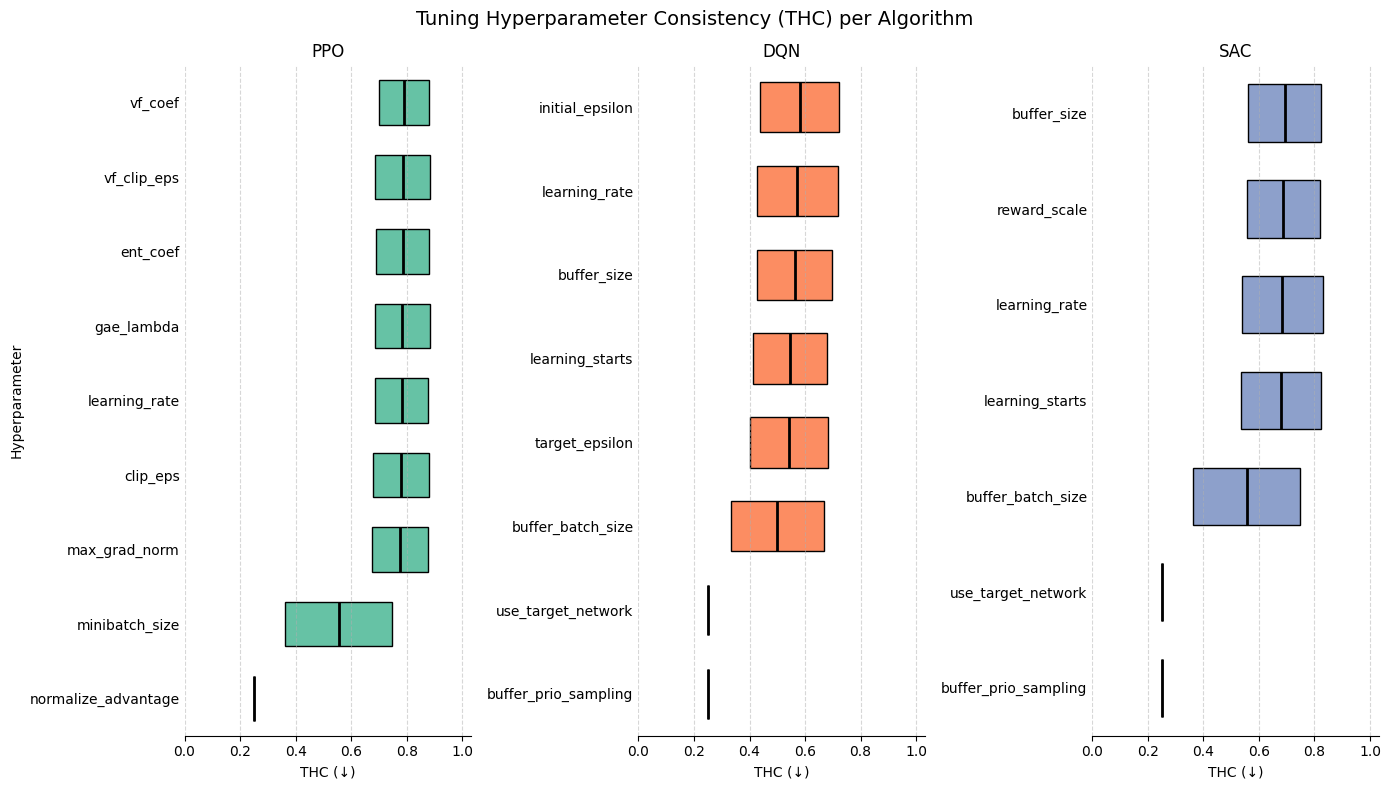

In [15]:
# Prepare data for seaborn
plot_data = []
for algo in algos:
    for H_i, stats in thc_summary[algo].items():
        if not np.isnan(stats["thc"]):
            plot_data.append({
                "algorithm": algo.upper(),
                "hyperparameter": H_i,
                "thc": stats["thc"],
                "thc_std": stats["thc_std"]
            })

plot_df = pd.DataFrame(plot_data)

fig, axes = plt.subplots(1, 3, figsize=(14, 8))
palette = sns.color_palette("Set2")

for idx, algo in enumerate(["PPO", "DQN", "SAC"]):
    ax = axes[idx]
    algo_df = plot_df[plot_df["algorithm"] == algo].sort_values(by="thc", ascending=True).reset_index(drop=True)
    
    for i, (_, row) in enumerate(algo_df.iterrows()):
        # Draw box centered at mean, extending std to left and right
        left = row["thc"] - row["thc_std"]
        right = row["thc"] + row["thc_std"]
        height = 0.6
        
        # Draw the box
        rect = plt.Rectangle(
            (left, i - height/2), 
            row["thc_std"] * 2,  # width = 2 * std
            height,
            facecolor=palette[idx],
            edgecolor="black",
            linewidth=1
        )
        ax.add_patch(rect)
        
        # Draw black line at the mean
        ax.vlines(row["thc"], i - height/2, i + height/2, color="black", linewidth=2)
    
    ax.set_yticks(range(len(algo_df)))
    ax.set_yticklabels(algo_df["hyperparameter"])
    ax.set_ylim(-0.5, len(algo_df) - 0.5)
    ax.set_xlim(0, plot_df["thc"].max() + plot_df["thc_std"].max() + 0.05)
    ax.set_xlabel("THC (↓)")
    ax.set_ylabel("Hyperparameter" if idx == 0 else "")
    ax.set_title(algo)
    
    # Add light grid
    ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=0)
    
    # Remove borders except bottom
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Remove y-axis ticks (keep labels)
    ax.tick_params(axis='y', length=0)

plt.suptitle("Tuning Hyperparameter Consistency (THC) per Algorithm", fontsize=14)
plt.tight_layout()

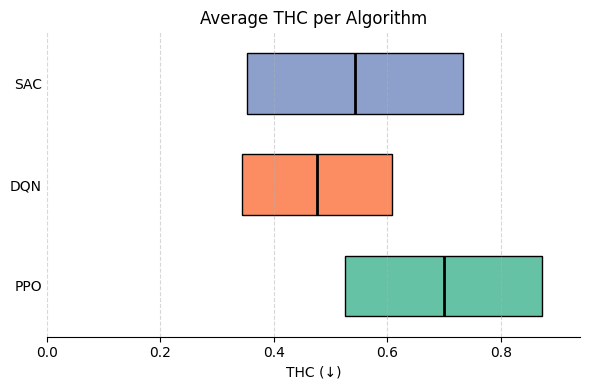

In [16]:
algo_rows = []
for algo in algos:
    vals = [s["thc"] for s in thc_summary[algo].values() if not np.isnan(s["thc"])]
    if not vals:
        continue
    algo_rows.append({"algorithm": algo.upper(), "thc": np.mean(vals), "thc_std": np.std(vals)})

algo_df = pd.DataFrame(algo_rows).set_index("algorithm").loc[["PPO", "DQN", "SAC"]].reset_index()

fig, ax = plt.subplots(figsize=(6, 4))
palette = sns.color_palette("Set2")
col_map = {"PPO": palette[0], "DQN": palette[1], "SAC": palette[2]}

y = np.arange(len(algo_df))
height = 0.6
for i, row in enumerate(algo_df.itertuples(index=False)):
    left = row.thc - row.thc_std
    width = row.thc_std * 2
    rect = plt.Rectangle((left, i - height/2), width, height,
                         facecolor=col_map[row.algorithm], edgecolor="black", linewidth=1)
    ax.add_patch(rect)
    ax.vlines(row.thc, i - height/2, i + height/2, color="black", linewidth=2)

ax.set_yticks(y)
ax.set_yticklabels(algo_df["algorithm"])
ax.set_xlabel("THC (↓)")
ax.set_xlim(0, algo_df["thc"].max() + algo_df["thc_std"].max() + 0.05)
ax.set_ylim(-0.5, len(algo_df) - 0.5)

# style
ax.grid(axis="x", linestyle="--", alpha=0.5, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)

plt.title("Average THC per Algorithm")
plt.tight_layout()
# plt.show()